In [ ]:
%pip install "git+https://github.com/Mishne-Lab/pyRATS[examples]"

In [ ]:
from matplotlib import pyplot as plt

from pyRATS import rats
import datasets, vis

import time

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

In [2]:
X, labels, ddX, _ = datasets.Datasets().curvedtorus3d(Rmax=0.3, n=5000)

X.shape =  (5000, 3)


# Generate embeddings

In [3]:
model = rats.RATS(
    n_components=2,
    n_neighbors=21,
    min_cluster_size=5,
    nu=3,
    n_iter=40,
    n_iter_without_progress=40,
    tear=True,
    cost_function='distortion'
)

start = time.time()

y = model.fit_transform(X=X)

end = time.time()
y, f'runtime: {end - start}'

(array([[-0.38240651,  0.54902067],
        [ 0.08745959,  0.24950518],
        [-0.44788344,  0.69900299],
        ...,
        [-0.54379846,  0.48575909],
        [-0.32594909,  0.66732036],
        [-0.16946249,  0.27300808]], shape=(5000, 2)),
 'runtime: 39.482577085494995')

# Tear coloring

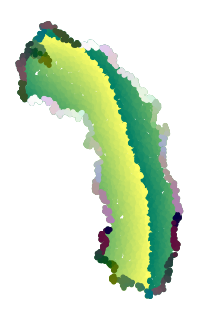

In [4]:
tear_color_eig_inds = [6, 1, 4] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer',
    title='color='+str(tear_color_eig_inds),
    figsize=(3,3)
)
plt.show()